# Pandas Assignment — Temperature Sensor Analysis

**Instructions:**
- Read each question **carefully before running any code cell**
- Write your answers in the `[YOUR ANSWER]` cells — these require written explanations, not just code
- Some code cells are intentionally left blank: you need to write the code yourself
- Focus on *why* things work, not just *what* to type

**Estimated time:** ~70 minutes

---
## Part 1 — Get to Know the Dataset (15 min)

You have been given a new dataset: `assignment_data.csv`.  
It contains measurements recorded by a temperature sensor in a lab environment.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('assignment_data.csv')
df

,time_s,temperature_C
0,0.00,26.226
1,0.01,20.835
2,0.02,22.082
3,0.03,23.019
4,0.04,20.028
...,...,...
1995,19.95,25.491
1996,19.96,26.951
1997,19.97,22.885
1998,19.98,21.358


**Q1.1** — Before using any pandas function, just from looking at the column names and the first few rows:
- What does each column represent?
- What unit does each column likely use?
- How often is the sensor sampling, in Hz? *(Hint: look at the time step between consecutive rows)*

> **[There are 2 columns, the first representing time (every hundreth of a second). The second column shows what the recorded temperature in degrees Celsius was at that point in time (ie, at 0.02 seconds, the temp was 20.835). There is also a count of all rows in the set, which in this case is 2000. ]**

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time_s         2000 non-null   float64
 1   temperature_C  1982 non-null   float64
dtypes: float64(2)
memory usage: 31.4 KB


In [12]:
df.describe()

,time_s,temperature_C
count,2000.000000,1982.000000
mean,9.995000,22.027869
std,5.774946,3.445123
min,0.000000,13.861000
25%,4.997500,20.246250
50%,9.995000,21.912500
75%,14.992500,23.610500
max,19.990000,73.082000


**Q1.2** — Look at the output of `df.info()` and `df.describe()` together:
- How many missing values are there in `temperature_C`? *(Hint: compare Non-Null Count to the total number of rows)*
- What is the maximum temperature recorded? Is that a realistic lab temperature? What do you suspect about those readings?

> **[There are 18 missing values in the temperature (2000 - 1982). The maximumm tempeature recorded is 73.082 degreees celsius, which is likely a one off misread by the instrument, since that is not a realistic lab temperature compared to the other values (with only 23.6 degrees being hotter than 75% of the temp values, no where close to 73 degrees).]**

In [13]:
df.isna().sum()

time_s            0
temperature_C    18
dtype: int64

**Q1.3** — Write a **single line of code** below to display only the rows where `temperature_C` is greater than 50.  
How many rows are there?

In [ ]:
# YOUR CODE HERE
df[df["temperature_C"]>50] 
#df gets a data set, the name is temperature c (brackets and double quotations needed) and then >50 to filter

,time_s,temperature_C
261,2.61,69.098
717,7.17,64.090
728,7.28,73.082
743,7.43,70.984
1322,13.22,70.786


**Q1.4** — Based on what you found above:
- What percentage of the 2000 rows do these high-temperature readings represent?
- Do you think they are real measurements or sensor errors? Justify your reasoning.

> **[These represent less than 1% of all sensor readings (5/2000 = 0.25%), so becuae of that, I think they are sensor errors. Genearlly speaking temperature would be related to eachother, and would not randomly spike from a temperature of less than 50 degrees celcius to higher than 64 degrees celsius without a more sustained increase. There would also be more data points than 5 (unless they were clumped together 5 in a row, which is not the case) so due to this , and knowing that 26.1 degrees is higher than 75% of all data inputs, i find it unlikely that these were real measurments, and most likely intrument errors]**

---
## Part 2 — Handling Missing Data (15 min)

**Q2.1** — **Before writing any code**, think about this scenario:  
If you use `df.fillna(0)` to replace the missing temperature values with 0:
- What temperature does 0 represent in Celsius?
- Is that a realistic lab temperature?
- What problem would this introduce when you later compute the mean?

> **[it would completely skew the average down. a temperature of 0 degrees celsius represents the freezing point of water and is well below the minimum recorded in the data set (which is 13.86 degrees celsuis). this is not a realistic lab temperature, and this would cuase the calculated average to decrease substantually, and skew the overall measurments of the data set. ]**

In [30]:
# Strategy A: drop rows with missing values
df_dropped = df.dropna()
print("Rows remaining after dropna():", len(df_dropped))
print("Rows lost:", len(df) - len(df_dropped))

Rows remaining after dropna(): 1982
Rows lost: 18


In [31]:
# Strategy B: fill missing values with the column mean
mean_temp = df['temperature_C'].mean()
df_filled = df.fillna(mean_temp)
print("Mean used to fill:", round(mean_temp, 3))
print("Missing values remaining:", df_filled['temperature_C'].isna().sum())

Mean used to fill: 22.028
Missing values remaining: 0


**Q2.2** — Compare the two strategies:
- Strategy A loses rows. Is losing roughly 1% of the data acceptable here? What could you lose along with it?
- Strategy B keeps all rows but replaces NaN with an estimate. Does that introduce any distortion into the data?
- Which strategy would you choose for this dataset, and why?

> **[I think that loosing 1% of data in this case is acceptable. What could be lost with it is increased precision, but a precision off by about 1% should not be a big deal *in most cases. The second strategy would intordiuce potential distortion into the data, making everything come closer to the mean. this could increase accuracy, but it could also skew things towards the center. I would choose strategy A - since we already have so miuch data, loosing approximately 1% of 2000 data sets still leaves us with a lot of data to work with and to be accurate.]**

In [41]:
# Apply your chosen strategy — change this if you prefer dropna()
df_clean = df.dropna()
print("Working dataset has", len(df_clean), "rows")

Working dataset has 1982 rows


---
## Part 3 — Visualise and Interpret (15 min)

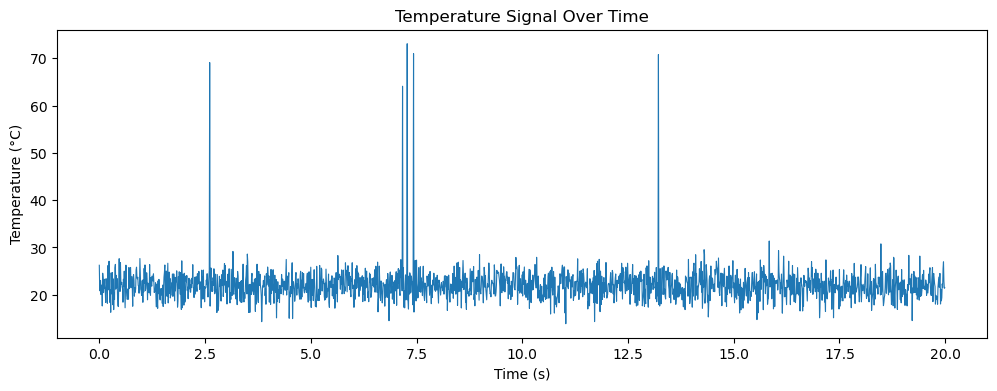

In [42]:
plt.figure(figsize=(12, 4))
plt.plot(df_clean['time_s'], df_clean['temperature_C'], linewidth=0.8)
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Signal Over Time')
plt.show()

**Q3.1** — Describe what you see in the plot:
- Is the signal noisy or smooth?
- Are there any obvious spikes or sudden jumps?
- Does the signal appear to increase, decrease, or stay roughly constant over time?

> **[The signal is realatively noisy, with some signifigant variation of about 10 degrees or more. there are 5 sudden spikes, which were found earlier by seeing which temp values were above 50 degrees celsius. the signal also appears to remian constant near about 22 degrees, with potential it is a sin wave, but it stays realatively around that same temperature + or - several degrees.  ]**

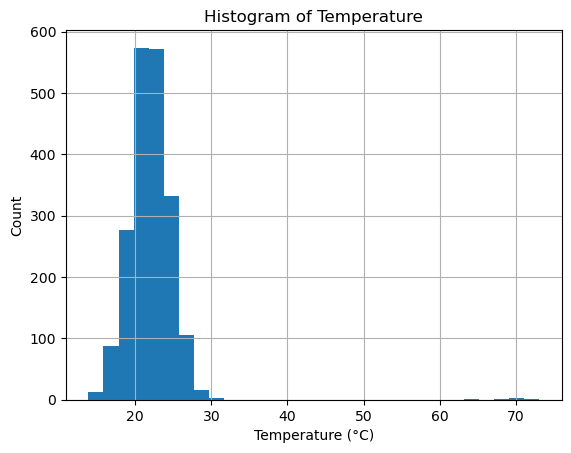

In [43]:
df_clean['temperature_C'].hist(bins=30)
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.title('Histogram of Temperature')
plt.show()

**Q3.2** — Look at the histogram:
- Is the main distribution roughly symmetric, or skewed?
- Do you see an isolated cluster of bars far to the right? What do those correspond to?
- If you removed those outlier readings, how would the histogram change?

> **[the main distribution is technically skewed. I do see a isolated cluster of bars far to the right, which correspond to the outlier sensor errors discussed earlier and the very tall spikes recorded. Once removed, the hisogram would be symmetric (since we would only consider the large collumns to the left, which are mostly symetric in isolation)]**

**Q3.3** — **Before running the cell below**, make a prediction:  
Given that the dataset contains a few very high temperature outliers, do you expect the mean to be **higher than**, **lower than**, or **about the same as** the median?  
Write your prediction and your reasoning first, then run the code to check.

> **[I predict that the mean will be higher than the median, since the outlier temperature will artificially skew the data set mean to be higher ]**

In [69]:
df['temperature_C'].mean()
# Compute and print the mean and median of temperature_C


np.float64(22.02786881937437)

In [70]:
df['temperature_C'].median()
# Compute and print the mean and median of temperature_C


np.float64(21.9125)

**Q3.4** — Was your prediction correct?  
In one sentence, explain *why* the mean and median behave differently when outliers are present.

> **[yes i was correct. the mean and median behave differenty when outliers are present becuase the mean relies on ALL the data, which inlcudes outliers. This can skew the mean as observed. however, the median is simply the most "middle" value when gathering the whole data set, so outliers do not affect the median, since it is reliant on its own position in comparison with the other data]**

---
## Part 4 — Smoothing the Signal (15 min)

A rolling average smooths a noisy signal by replacing each value with the average of the surrounding samples.  
You control how much smoothing by choosing the **window size** (number of samples used per average).

**Q4.1** — **Before running any code**, use the sampling rate to reason about window sizes:  
The sensor samples at 100 Hz (100 samples per second).
- What time duration (in seconds) does a window of 10 samples represent?
- What time duration does a window of 200 samples represent?

> **[the time duration that a window of 10 represents is 0.1 seconds. the time duration that a window of 200 samples represents is 2 seconds (1/100 sec x 10, 1/100 x 200)]**

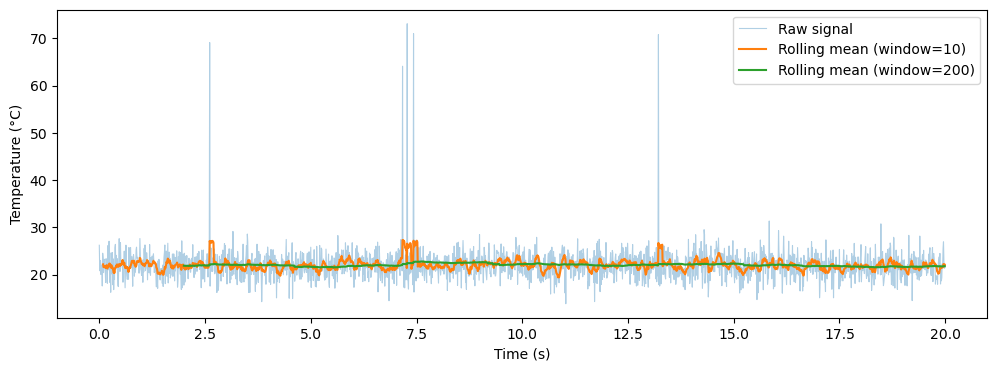

In [71]:
df_clean['rolling_10'] = df_clean['temperature_C'].rolling(window=10).mean()
df_clean['rolling_200'] = df_clean['temperature_C'].rolling(window=200).mean()

plt.figure(figsize=(12, 4))
plt.plot(df_clean['time_s'], df_clean['temperature_C'], alpha=0.35, linewidth=0.8, label='Raw signal')
plt.plot(df_clean['time_s'], df_clean['rolling_10'], linewidth=1.5, label='Rolling mean (window=10)')
plt.plot(df_clean['time_s'], df_clean['rolling_200'], linewidth=1.5, label='Rolling mean (window=200)')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

**Q4.2** — Compare the two smoothed signals in the plot:
- Which one tracks the raw signal more closely?
- Which one produces the smoother result?
- At the very beginning of the plot, why does `rolling_200` start later than `rolling_10`?

> **[the window of 10 tracks the raw signal more clsosely. the window of 200 produces a smoother result. At the beginning the rolling 200 starts later becuase it needs 200 inputs before it can begin, which comes 2 seconds after the start compared to the window of 10 which only needs .1 seconds before it can start recording the average]**

In [72]:
print("Std of raw signal:    ", round(df_clean['temperature_C'].std(), 4))
print("Std of rolling_10:    ", round(df_clean['rolling_10'].std(), 4))
print("Std of rolling_200:   ", round(df_clean['rolling_200'].std(), 4))

Std of raw signal:     3.4451
Std of rolling_10:     1.0585
Std of rolling_200:    0.2742


**Q4.3** — The standard deviation decreases as the window gets larger.  
Imagine you are building an alarm system that must detect a **sudden large temperature spike** within 0.5 seconds of it happening.  
- Would you use a small or large rolling window? Why?  
- What do you *trade away* by using a larger window?

> **[I would use a small rolling window, since it follows the raw signal more clsoely. a rolling window of 200 in this case would take too long to detect a large sudden temperature spike. I trade away reaction time by using a larger window, as it would detect a rising temperature more slowly becuase of its larger window for its averages.]**

---
## Part 5 — Outlier Investigation (10 min)

**Q5.1** — Write code below to:
1. Count how many rows have `temperature_C > 50`
2. Compute what percentage of the total dataset that represents (round to 2 decimal places)

Print both values with clear labels.

In [93]:
# YOUR CODE HERE
Row_Count =len(df[df["temperature_C"]>50]) #this counts the number of rows, and i use the same function I made earlier + len
Percent =(Row_Count / len(df.dropna())) * 100 #since i dropped the rows without input, i take that into consideration here with len df dropna
print(f"Number of rows is{Row_Count}")
print(f"This is {Percent}% of the dataset")

Number of rows is5
This is 0.2522704339051463% of the dataset


In [94]:
# Mean and median WITH outliers
mean_with = df_clean['temperature_C'].mean()
median_with = df_clean['temperature_C'].median()

# Mean and median WITHOUT outliers
df_no_outliers = df_clean[df_clean['temperature_C'] <= 50]
mean_without = df_no_outliers['temperature_C'].mean()
median_without = df_no_outliers['temperature_C'].median()

print(f"Mean     WITH outliers: {mean_with:.3f}")
print(f"Mean  WITHOUT outliers: {mean_without:.3f}")
print()
print(f"Median   WITH outliers: {median_with:.3f}")
print(f"Median WITHOUT outliers: {median_without:.3f}")

Mean     WITH outliers: 22.028
Mean  WITHOUT outliers: 21.908

Median   WITH outliers: 21.913
Median WITHOUT outliers: 21.887


**Q5.2** — Look at the numbers above:
- Which statistic changed more when outliers were removed — the mean or the median?
- In one sentence, explain *why* the median is more resistant to outliers than the mean.

> **[mean changed more. The median is more reistant to outliers than the mean becuase the median is "median is the middle value in a dataset when all the numbers are arranged in ascending or descending order", meaning that it is simply the 50% point in the data set and mainly focuses on the number of data points, rather than computing the average which considers all data points AND their values]**

**Q5.3** — Imagine you are a lab technician reviewing this data.  
Give **one reason why you might remove** the outliers and **one reason why you might keep** them.

> **[You might remove the outliers becuase they could skew the data set, as shown here. They are likley sensor issues and instead skew the average and other data. However, one reason you may keep them is if they make up a large percentage of the data and is best not to be discarded]**

---
## Bonus — Putting It All Together *(optional)*

Using everything you have learned, create a **single, well-labelled plot** that shows:
- The raw signal (with low opacity)
- The smoothed signal using the window size you think is most appropriate
- Two horizontal lines: one for the mean and one for the median of the clean signal *(without outliers)*

Add a title, axis labels, and a legend. No written answer required — make it clear and informative.

In [95]:
# YOUR CODE HERE
